## Variance in Linear Regression

This notebook explores how different levels of noise (variance) in the training data affect a linear regression model trained with SGD. We generate several datasets sampled from the same underlying signal but with increasing amounts of noise, train one model per dataset, and then compare their training dynamics and learned parameters.

In [15]:
import numpy as np

SLOPE = 3.5
INTERCEPT = 7.1

"""Signal to estimate"""
def f(x: np.ndarray) -> np.ndarray:
    return x*SLOPE + INTERCEPT

coefs = np.array([
    [SLOPE],
    [INTERCEPT]
])

In [16]:
"""Generate dataset helper"""

import numpy as np

MIN = -7
MAX = 7
SEED = 777

def generate_dataset(size: int, sample_size: int, noise_upto: float) -> np.ndarray:
    rng = np.random.default_rng(SEED)
    x = rng.uniform(MIN, MAX, sample_size)
    y = f(x)
    y_noise = None

    datasets: list[np.ndarray] = []

    for noise in np.linspace(0, noise_upto, size):
        y_noise = y + rng.standard_normal(x.shape[0]) * noise
        sample = np.stack([x, y_noise]).T

        datasets.append(sample)

    return np.stack(datasets[:])

## How the data is built

The `generate_dataset` function builds a stack of datasets with progressively higher variance along `axis=0`. Each dataset shares the same `x` samples and clean signal `y = f(x)`, but a different amount of Gaussian noise is added to `y`. The noise levels are equally spaced between `0` and `noise_upto`, so the first dataset in the stack is noise-free and the last one has the highest variance. The larger `noise_upto` is, the noisier (and more spread out) the final dataset becomes.

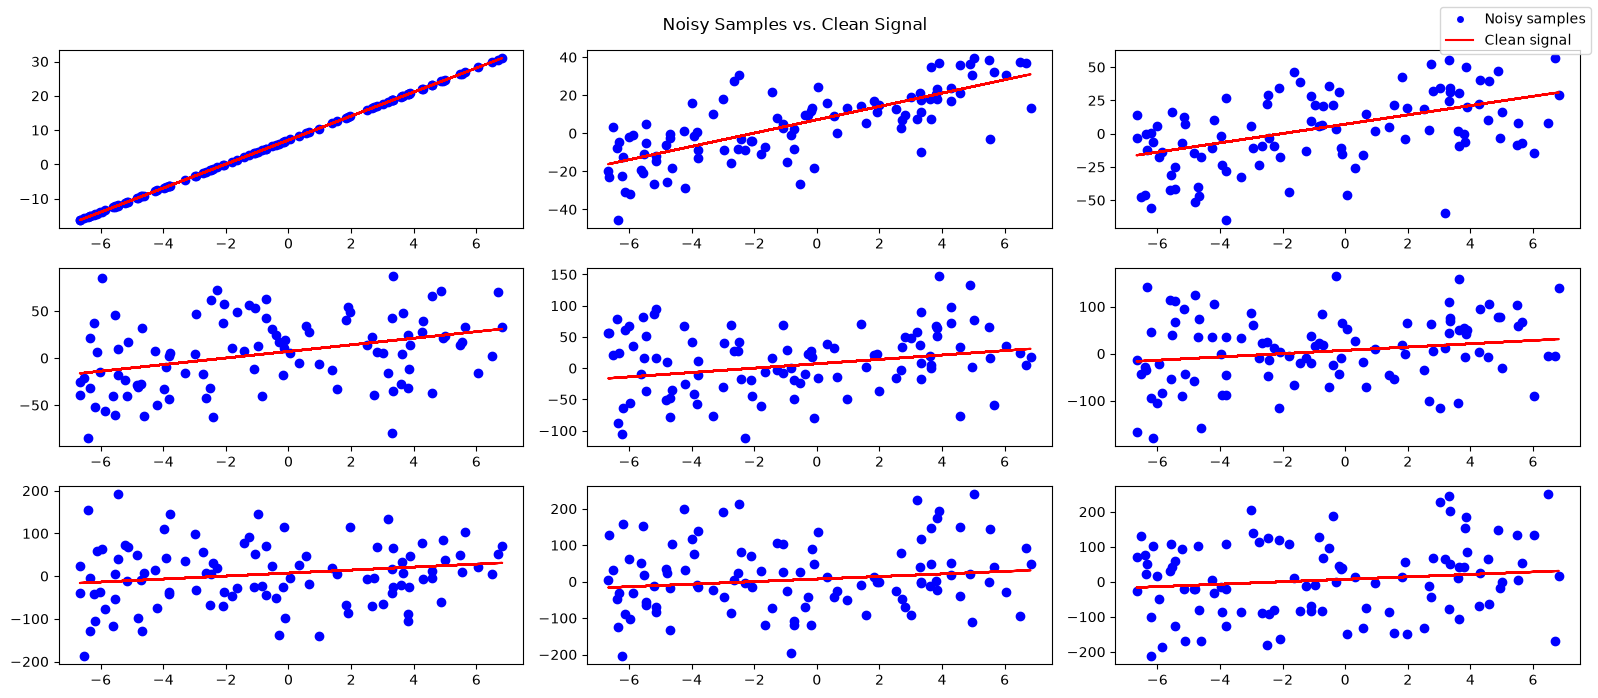

In [17]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from examples.helpers.graph import generate_axs, plot_dataset, scatter_dataset

DATASETS_SIZE = 9
SAMPLE_SIZE = 100
NOISE_UPTO = 100

X = generate_dataset(size=DATASETS_SIZE, sample_size=SAMPLE_SIZE, noise_upto=NOISE_UPTO)
X_clean = generate_dataset(size=DATASETS_SIZE, sample_size=SAMPLE_SIZE, noise_upto=0)

fig, axs = generate_axs(X.shape[0])
scatter_dataset(X, fig, axs)
plot_dataset(X_clean, fig, axs)

fig.suptitle("Noisy Samples vs. Clean Signal")
fig.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Noisy samples'),
    Line2D([0], [0], color='red', label='Clean signal'),
], loc='upper right')

fig.tight_layout()
plt.show()

## Training the models

We instantiate one model per dataset (one per noise level), each with its own trainer, then train them all with the `fit_models` function using the same hyperparameters (epochs, batch size, and a cosine-annealed learning rate between `MIN_LR` and `MAX_LR`).

`BATCH_SIZE` is set to `1` to extract the best performance from each model

In [18]:
from core.training import Trainer
from examples.helpers.train import create_trainer, fit_models, split_dataset


EPOCHS = 200
EVAL_STEP = 10
BATCH_SIZE = 1
MAX_LR, MIN_LR = 1e-2, 1e-4


trainers: list[Trainer] = []
X_tr, X_te = split_dataset(X, split_ratio=0.9, axis=1)

for i in range(DATASETS_SIZE):
    trainer = create_trainer(X.shape[2]-1, X.shape[2]-1, MIN_LR, MAX_LR, EPOCHS)
    trainers.append(trainer)

fit_models(trainers, X_tr, X_te, EPOCHS, EVAL_STEP, BATCH_SIZE)

## Loss history

We plot the training and evaluation loss curves for every model side by side, one subplot per noise level. Train loss is shown in blue and evaluation loss in red, making it easy to see how higher variance in the dataset slows convergence and increases the gap between train and eval loss.

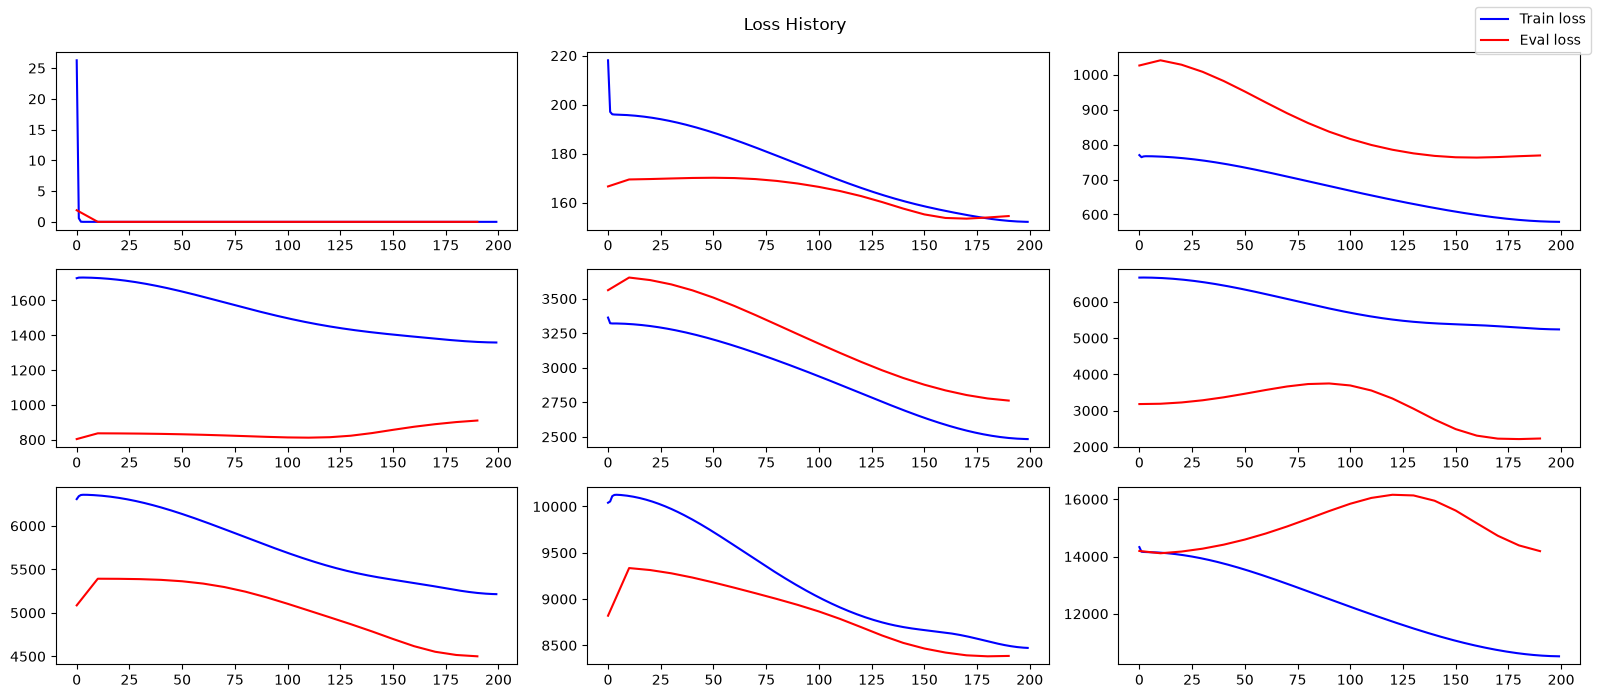

In [19]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from examples.helpers.graph import generate_axs, plot_dataset

fig, axs = generate_axs(len(trainers))

train_loss_history = []
eval_loss_history = []

for trainer in trainers:
    train_loss_history.append([range(EPOCHS), trainer.train_loss])
    eval_loss_history.append([range(0, EPOCHS, EVAL_STEP), trainer.eval_loss])

train_loss_history = np.array(train_loss_history)
eval_loss_history = np.array(eval_loss_history)

plot_dataset(train_loss_history, fig, axs, color='blue', axis=-1)
plot_dataset(eval_loss_history, fig, axs, color='red', axis=-1)

fig.suptitle("Loss History")
fig.legend(handles=[
    Line2D([0], [0], color='blue', label='Train loss'),
    Line2D([0], [0], color='red', label='Eval loss'),
], loc='upper right')

fig.tight_layout()
plt.show()

In [20]:
from core.layers import Sequential


def get_model_param(model: Sequential) -> np.ndarray:
    param = model.parameters
    weights, bias = param
    bias = bias.reshape(-1, 1)

    param = np.array([weights, bias])
    return param

def get_models_params(models: list[Sequential]) -> np.ndarray:
    params = []
    for model in models:
        local_param = get_model_param(model)
        params.append(local_param)

    return np.array(params)

## Weights interpretation

Finally, we extract the learned weight and bias from each trained model and plot them as bar charts (one per noise level), alongside the true coefficients used to generate the data. Learned weights are shown in blue and the true coefficients in red, showing how increasing noise pulls the estimated parameters further away from their true values.

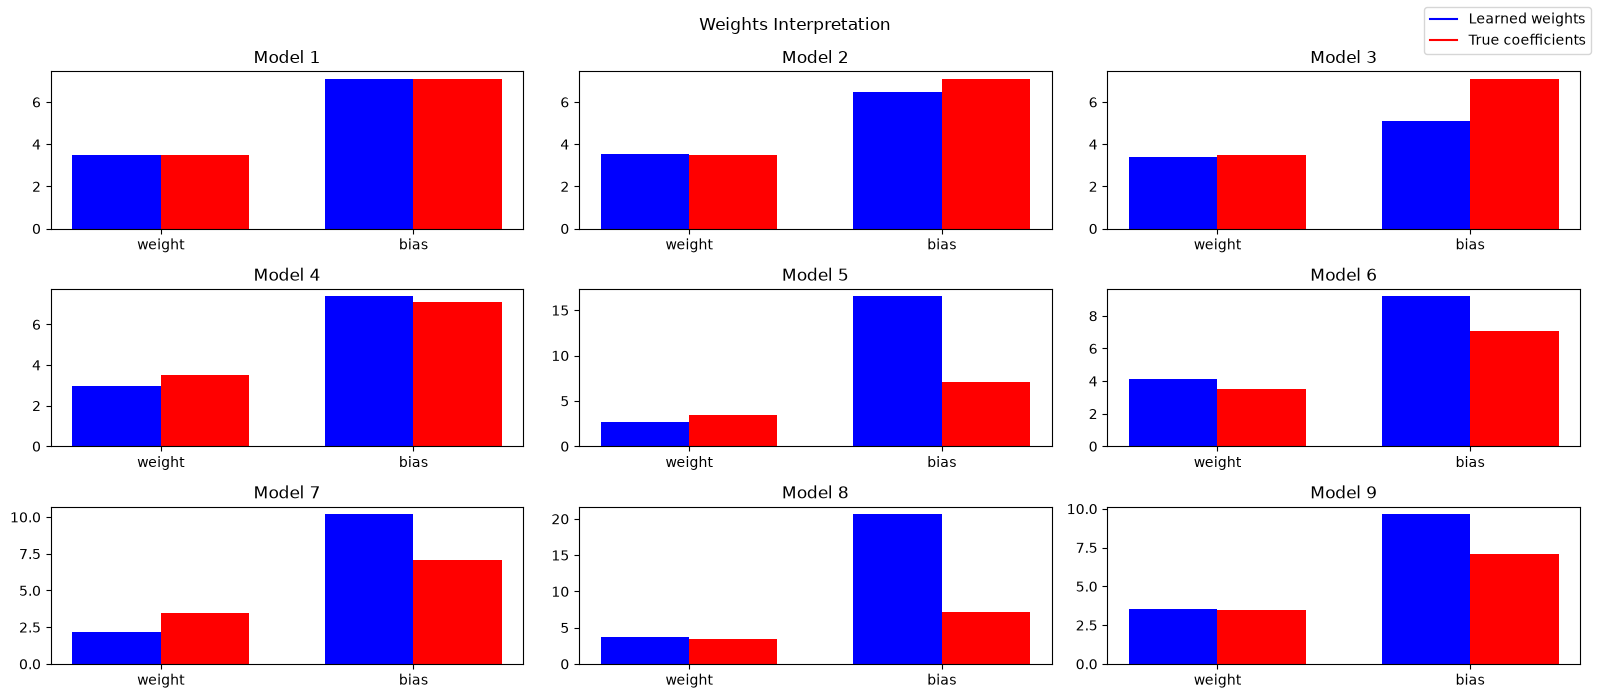

In [21]:
from matplotlib.lines import Line2D
from examples.helpers.graph import bar_dataset

fig, axs = generate_axs(len(trainers))

models_params = get_models_params([trainer.model for trainer in trainers])

bar_dataset(models_params, coefs, fig, axs)

fig.suptitle("Weights Interpretation")
fig.legend(handles=[
    Line2D([0], [0], color='blue', label='Learned weights'),
    Line2D([0], [0], color='red', label='True coefficients'),
], loc='upper right')

fig.tight_layout()
plt.show()